In [1]:
#Gaussian Channel as DataSet

import pandas as pd
import numpy as np

# =========================
# Parâmetros
# =========================
V_mod = 1
excess_noise = 0.02
rho = 0.0
tau = 0.2
realizacoes = 1000

mu = np.array([0, 0])

# =========================
# Alice ~ N(0, I)
# =========================
samples_Alice = np.random.multivariate_normal(mu, np.eye(2), realizacoes)

Alice_df = pd.DataFrame(samples_Alice, columns=['P', 'Q'])

# =========================
# Ruído (heterodyne)
# =========================
sigma_x2 = (1 + (excess_noise / 2)) / ((tau / 2) * V_mod)

cov_y = np.array([
    [sigma_x2, sigma_x2 * rho],
    [sigma_x2 * rho, sigma_x2]
])

ruido = np.random.multivariate_normal(mu, cov_y, realizacoes)

# =========================
# Bob
# =========================
samples_Bob = samples_Alice + ruido
Bob_df = pd.DataFrame(samples_Bob, columns=['P', 'Q'])

display(Bob_df)

,P,Q
0,4.287669,1.029783
1,-2.520361,1.644833
2,3.141763,0.002462
3,6.035996,1.528401
4,2.650581,-2.999768
...,...,...
995,-0.477617,1.666594
996,-6.280651,-0.612758
997,-2.510723,2.603366
998,1.844083,5.137444


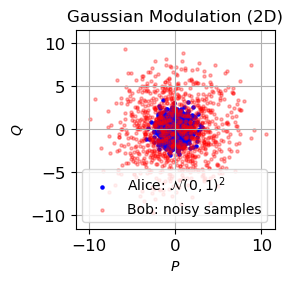

In [7]:
# =========================
# Plot - Alice and Bob samples
# =========================

import matplotlib.pyplot as plt 



plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "figure.figsize": (3, 3)
})

fig, ax = plt.subplots()

# Alice
ax.scatter(
    samples_Alice[:, 0],
    samples_Alice[:, 1],
    s=5,
    color='blue',
    #alpha=0.5,
    label=r'Alice: $\mathcal{N}(0,1)^2$'
)

# Bob
ax.scatter(
    samples_Bob[:, 0],
    samples_Bob[:, 1],
    s=5,
    color='red',
    alpha=0.3,
    label='Bob: noisy samples'
)

# Estética
ax.set_xlabel(r'$P$')
ax.set_ylabel(r'$Q$')
ax.set_title('Gaussian Modulation (2D)')
ax.legend()
ax.grid(True)
ax.set_aspect('equal', adjustable='box')

# Limites simétricos
lim = np.max(np.abs(samples_Bob)) * 1.1
ax.set_xlim([-lim, lim])
ax.set_ylim([-lim, lim])

plt.tight_layout()
"""sns.kdeplot(
    x=samples_Bob[:,0],
    y=samples_Bob[:,1],
    levels=10,
    linewidths=1
)"""

plt.savefig("Bidimensional_gaussian.png", dpi=300)
plt.show()


In [2]:
# Generating DataFrames with SNRs
import numpy as np
import pandas as pd

V_mod_tilde = 1
excess_noise=0.02
tau = np.arange(0.02, 0.28, 0.02, dtype=np.float32) #transmitância (40 pontos)
D = -np.log10(tau)*(10/0.2) # tau = 10^(-alpha*d/10)
V_mod = 4 * V_mod_tilde
nbits = 4

SNR_list = (tau * (V_mod) / (1 + excess_noise)).astype(np.float32) #homodyne
#SNR_list = ((tau/2) * (V_mod) / (1 + (excess_noise/2))).astype(np.float32) #heterodyne
SNRdB_list = (10 * np.log10(SNR_list))

# importing results of 4 channels
Capacity_P = np.loadtxt('Capacity_P_heterodyne.txt', dtype=np.float32)
Capacity_Q = np.loadtxt('Capacity_Q_heterodyne.txt', dtype=np.float32)
Pe_P = np.loadtxt('PE_P_heterodyne.txt', dtype = np.float32)
Pe_Q = np.loadtxt('PE_Q_heterodyne.txt', dtype = np.float32)

channels = ['ch1', 'ch2', 'ch3', 'ch4']

rows = []

for snr in range(len(SNRdB_list)):
    for channel in range(nbits):
        rows.append([SNRdB_list[snr], 'P', channel+1, Pe_P[snr, channel], Capacity_P[snr,channel]])
        rows.append([SNRdB_list[snr], 'Q', channel+1, Pe_Q[snr, channel], Capacity_Q[snr,channel]])
        
df = pd.DataFrame(rows, columns=["SNR", "Quadrature", "Channel", "Pe", "Capacity"]) #where C is the channel capacity
display(df.head(15))



,SNR,Quadrature,Channel,Pe,Capacity
0,-11.055101,P,1,0.437383,0.011407
1,-11.055101,Q,1,0.437778,0.011287
2,-11.055101,P,2,0.478510,0.001404
3,-11.055101,Q,2,0.477390,0.001548
4,-11.055101,P,3,0.492544,0.000220
5,-11.055101,Q,3,0.492068,0.000252
6,-11.055101,P,4,0.496784,0.000098
7,-11.055101,Q,4,0.498015,0.000081
8,-8.044802,P,1,0.412470,0.022283
9,-8.044802,Q,1,0.412506,0.022270


In [3]:
print(f"Info: {df.info()}")
print(f"Description: {df.describe()}")
print(f"Nulo? {df.isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SNR         104 non-null    float32
 1   Quadrature  104 non-null    object 
 2   Channel     104 non-null    int64  
 3   Pe          104 non-null    float32
 4   Capacity    104 non-null    float32
dtypes: float32(3), int64(1), object(1)
memory usage: 3.0+ KB
Info: None
Description:               SNR     Channel          Pe    Capacity
count  104.000000  104.000000  104.000000  104.000000
mean    -3.521040    2.500000    0.441401    0.019959
std      3.209318    1.123448    0.058094    0.032444
min    -11.055101    1.000000    0.301709    0.000081
25%     -5.034502    1.750000    0.422324    0.000614
50%     -2.604121    2.500000    0.467949    0.003040
75%     -1.055102    3.250000    0.486245    0.017567
max      0.084331    4.000000    0.498015    0.116698
Nulo? SNR           0
Quadrature    0

In [19]:
df["Entropy"] = 1-df["Capacity"]

display(df)



,SNR,Quadrature,Channel,Pe,Capacity,Entropy
0,-11.055101,P,1,0.437383,0.011407,0.988593
1,-11.055101,Q,1,0.437778,0.011287,0.988713
2,-11.055101,P,2,0.478510,0.001404,0.998596
3,-11.055101,Q,2,0.477390,0.001548,0.998452
4,-11.055101,P,3,0.492544,0.000220,0.999780
...,...,...,...,...,...,...
99,0.084331,Q,2,0.419612,0.018802,0.981198
100,0.084331,P,3,0.466265,0.003351,0.996648
101,0.084331,Q,3,0.465358,0.003533,0.996467
102,0.084331,P,4,0.485103,0.000713,0.999287


In [20]:
assert (df["Pe"] >= 0).all() and (df["Pe"] <= 0.5).all()
assert (df["Capacity"] >= 0).all()

df_group = df.groupby(['SNR', 'Quadrature']).agg({
    'Pe': ['mean','std','min','max'],
    'Capacity': ['mean','std']
}).reset_index()

display(df_group)

SNR Quadrature        Pe                                Capacity  \
                              mean       std       min       max      mean   
0  -11.055101          P  0.476305  0.027098  0.437383  0.496784  0.003282   
1  -11.055101          Q  0.476313  0.027113  0.437778  0.498015  0.003292   
2   -8.044802          P  0.466327  0.037807  0.412470  0.496000  0.006465   
3   -8.044802          Q  0.466434  0.037865  0.412506  0.496249  0.006454   
4   -6.283889          P  0.458837  0.045627  0.394000  0.494811  0.009537   
5   -6.283889          Q  0.458956  0.045489  0.394092  0.494693  0.009476   
6   -5.034502          P  0.452717  0.051570  0.379118  0.493062  0.012387   
7   -5.034502          Q  0.452851  0.051610  0.379629  0.494237  0.012351   
8   -4.065402          P  0.447321  0.056810  0.366482  0.492635  0.015224   
9   -4.065402          Q  0.447370  0.056574  0.366882  0.491917  0.015152   
10  -3.273590          P  0.442717  0.061014  0.355993  0.491527  0.017815   
11  -3.273590          Q  0.442658  0.061004  0.355924  0.491387  0.017831   
12  -2.604121          P  0.438461  0.065464  0.345553  0.491118  0.020558   
13  -2.604121          Q  0.438149  0.065166  0.345638  0.489983  0.020593   
14  -2.024202          P  0.434503  0.068702  0.336899  0.489471  0.023023   
15  -2.024202          Q  0.434188  0.068560  0.336790  0.489009  0.023103   
16  -1.512677          P  0.430740  0.071980  0.328555  0.488370  0.025567   
17  -1.512677          Q  0.430804  0.071699  0.329282  0.488621  0.025450   
18  -1.055102          P  0.427191  0.074649  0.321350  0.487256  0.027957   
19  -1.055102          Q  0.427167  0.074699  0.321470  0.487689  0.027989   
20  -0.641175          P  0.423934  0.077371  0.314327  0.486579  0.030346   
21  -0.641175          Q  0.423934  0.077433  0.314149  0.486627  0.030362   
22  -0.263289          P  0.421279  0.079982  0.308076  0.486130  0.032510   
23  -0.263289          Q  0.421054  0.079997  0.307654  0.485789  0.032613   
24   0.084331          P  0.418447  0.082084  0.302339  0.485103  0.034646   
25   0.084331          Q  0.417762  0.082003  0.301709  0.484368  0.034950   

              
         std  
0   0.005448  
1   0.005370  
2   0.010626  
3   0.010622  
4   0.015606  
5   0.015591  
6   0.020329  
7   0.020129  
8   0.024809  
9   0.024656  
10  0.028882  
11  0.028906  
12  0.033275  
13  0.033214  
14  0.037147  
15  0.037167  
16  0.041083  
17  0.040692  
18  0.044608  
19  0.044526  
20  0.048226  
21  0.048334  
22  0.051604  
23  0.051844  
24  0.054765  
25  0.055072

,SNR,Quadrature,Channel,Pe,Capacity
0,-11.055101,P,1,0.437383,0.011407
2,-11.055101,P,2,0.478510,0.001404
4,-11.055101,P,3,0.492544,0.000220
6,-11.055101,P,4,0.496784,0.000098
8,-8.044802,P,1,0.412470,0.022283


,SNR,Quadrature,Channel,Pe,Capacity
1,-11.055101,Q,1,0.437778,0.011287
3,-11.055101,Q,2,0.477390,0.001548
5,-11.055101,Q,3,0.492068,0.000252
7,-11.055101,Q,4,0.498015,0.000081
9,-8.044802,Q,1,0.412506,0.022270


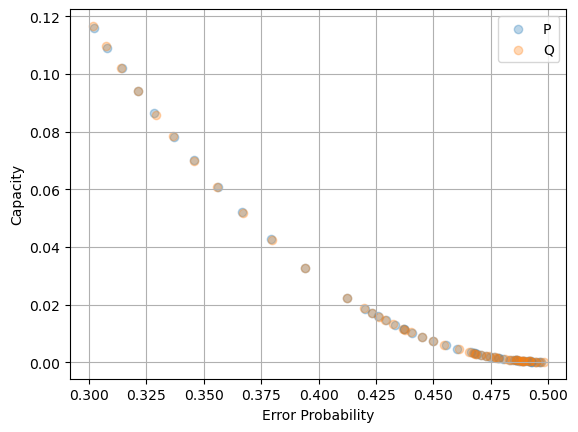

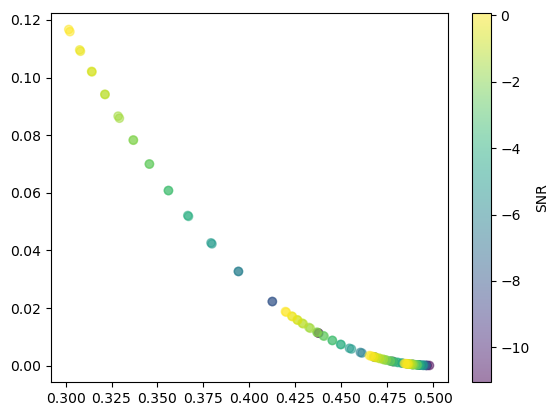

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

### Scatter plot for quadrature (all channels in the same Figure) ####

for quad in ['P', 'Q']:
    subset = df[df["Quadrature"] == quad]
    display(subset.head())
    #print(len(subset))
    
    plt.scatter(subset["Pe"], subset["Capacity"], alpha=0.3, label=quad)

plt.xlabel("Error Probability")
plt.ylabel("Capacity")
plt.legend()
plt.grid()
plt.show()

### Here, the same scatter, with a colorbar separating SNRs ####
# it is possible verify different channels, based on SNR variation

plt.scatter(
    df["Pe"],
    df["Capacity"],
    c=df["SNR"],
    cmap="viridis",
    alpha=0.5
)
plt.colorbar(label="SNR")

<Axes: xlabel='Pe', ylabel='Capacity'>

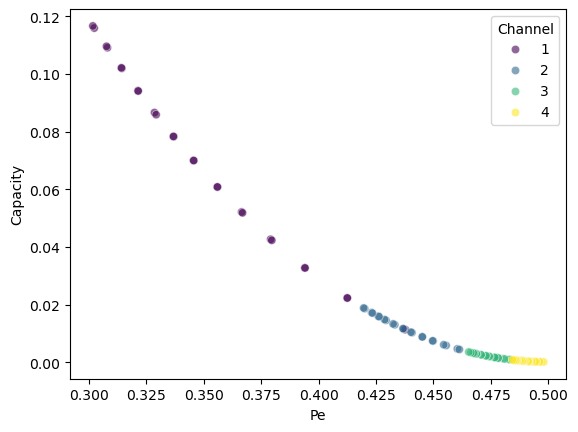

In [10]:
import seaborn as sns

### Here, the same scatter, but each channel presents a different color
sns.scatterplot(
    data=df,
    x="Pe",
    y="Capacity",
    hue="Channel",
    palette="viridis",
    alpha=0.6
)

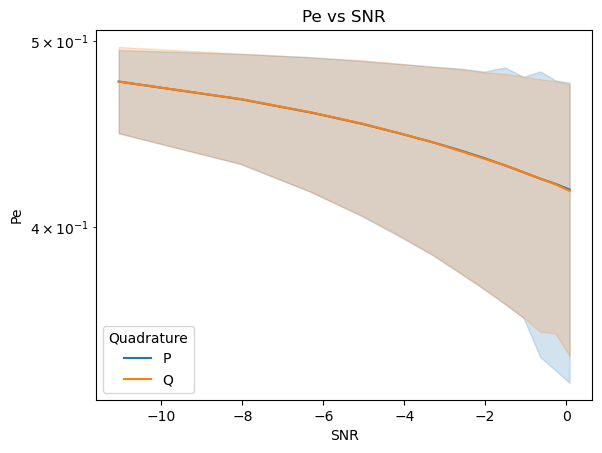

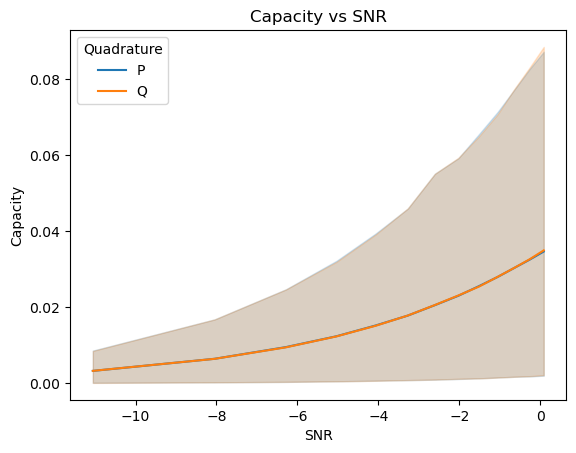

In [11]:
sns.lineplot(data=df, x="SNR", y="Pe", hue="Quadrature", estimator="mean")
plt.yscale("log")
plt.title("Pe vs SNR")
plt.show()

sns.lineplot(data=df, x="SNR", y="Capacity", hue="Quadrature", estimator="mean")
plt.title("Capacity vs SNR")
plt.show()

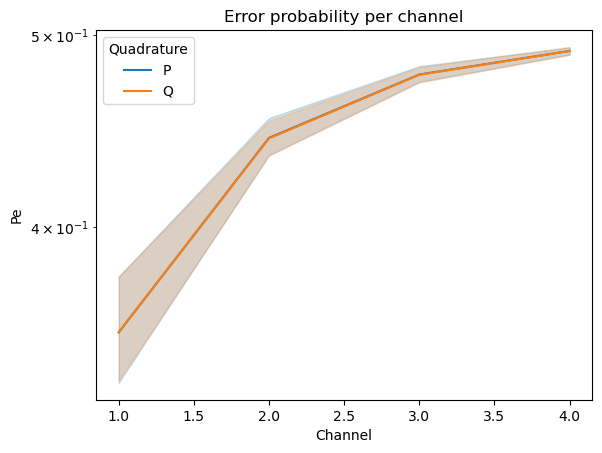

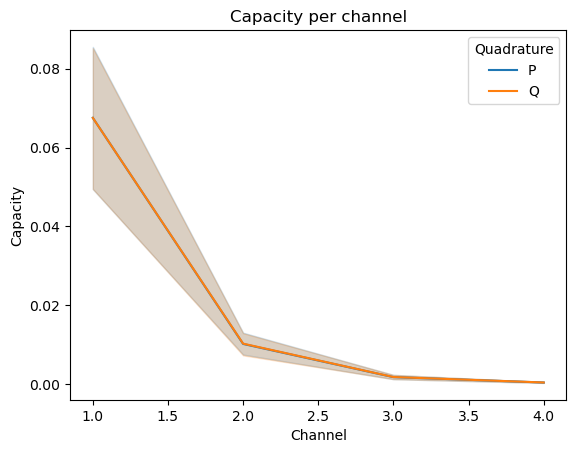

In [12]:
sns.lineplot(data=df, x="Channel", y="Pe", hue="Quadrature")
plt.yscale("log")
plt.title("Error probability per channel")
plt.show()

sns.lineplot(data=df, x="Channel", y="Capacity", hue="Quadrature")
plt.title("Capacity per channel")
plt.show()

,Pe,Capacity
Pe,1.000000,-0.964547
Capacity,-0.964547,1.000000


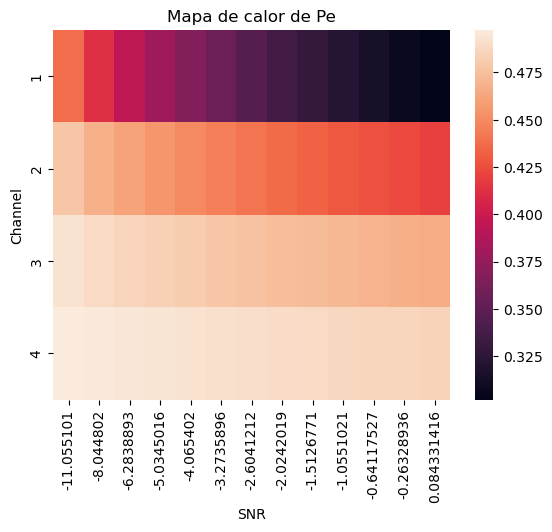

In [13]:
df_corr = df[["Pe", "Capacity"]].corr()
display(df_corr) #as the values are inversely proportional, the correlation is negative

sns.heatmap(df.pivot_table(
    index="Channel",
    columns="SNR",
    values="Pe"
))
plt.title("Mapa de calor de Pe")
plt.show()

In [14]:
df_pivot = df.pivot_table(
    index=["SNR", "Channel"],
    columns="Quadrature",
    values="Pe" #podemos mudar os valores da pivot_table
).reset_index()

df_pivot["delta_Pe"] = df_pivot["P"] - df_pivot["Q"]
display(df_pivot)

Quadrature,SNR,Channel,P,Q,delta_Pe
0,-11.055101,1,0.437383,0.437778,-0.000395
1,-11.055101,2,0.478510,0.477390,0.001120
2,-11.055101,3,0.492544,0.492068,0.000476
3,-11.055101,4,0.496784,0.498015,-0.001232
4,-8.044802,1,0.412470,0.412506,-0.000036
5,-8.044802,2,0.468058,0.468165,-0.000106
6,-8.044802,3,0.488778,0.488816,-0.000038
7,-8.044802,4,0.496000,0.496249,-0.000250
8,-6.283889,1,0.394000,0.394092,-0.000092
9,-6.283889,2,0.460403,0.461290,-0.000887


In [28]:
#Generating a group per quadrature, to obtain quadrature efficiency

df_quadrature = df.groupby(["SNR", "Quadrature"])["Capacity"].sum().reset_index()

display(df_quadrature)

for quad in df_quadrature["Quadrature"].unique():
    subset = df_quadrature[df_quadrature["Quadrature"] == quad]

#no bpsk a gente tem ao fim e ao cabo, 2 bits por uso do canal. Aqui a ideia é essa também. Então,
#só somamos as capacidades das quadraturas?

df_quadrature["Total Capacity"] = df_quadrature.groupby(["SNR"])["Capacity"].sum().reset_index
display(df_quadrature)

,SNR,Quadrature,Capacity
0,-11.055101,P,0.013130
1,-11.055101,Q,0.013169
2,-8.044802,P,0.025861
3,-8.044802,Q,0.025816
4,-6.283889,P,0.038148
5,-6.283889,Q,0.037905
6,-5.034502,P,0.049548
7,-5.034502,Q,0.049404
8,-4.065402,P,0.060896
9,-4.065402,Q,0.060607


,SNR,Quadrature,Capacity,Total Capacity
0,-11.055101,P,0.013130,<bound method Series.reset_index of SNR\n-11.0...
1,-11.055101,Q,0.013169,<bound method Series.reset_index of SNR\n-11.0...
2,-8.044802,P,0.025861,<bound method Series.reset_index of SNR\n-11.0...
3,-8.044802,Q,0.025816,<bound method Series.reset_index of SNR\n-11.0...
4,-6.283889,P,0.038148,<bound method Series.reset_index of SNR\n-11.0...
5,-6.283889,Q,0.037905,<bound method Series.reset_index of SNR\n-11.0...
6,-5.034502,P,0.049548,<bound method Series.reset_index of SNR\n-11.0...
7,-5.034502,Q,0.049404,<bound method Series.reset_index of SNR\n-11.0...
8,-4.065402,P,0.060896,<bound method Series.reset_index of SNR\n-11.0...
9,-4.065402,Q,0.060607,<bound method Series.reset_index of SNR\n-11.0...


,SNR,Quadrature,Capacity
0,-11.055101,P,0.013130
1,-11.055101,Q,0.013169
2,-8.044802,P,0.025861
3,-8.044802,Q,0.025816
4,-6.283889,P,0.038148
5,-6.283889,Q,0.037905
6,-5.034502,P,0.049548
7,-5.034502,Q,0.049404
8,-4.065402,P,0.060896
9,-4.065402,Q,0.060607


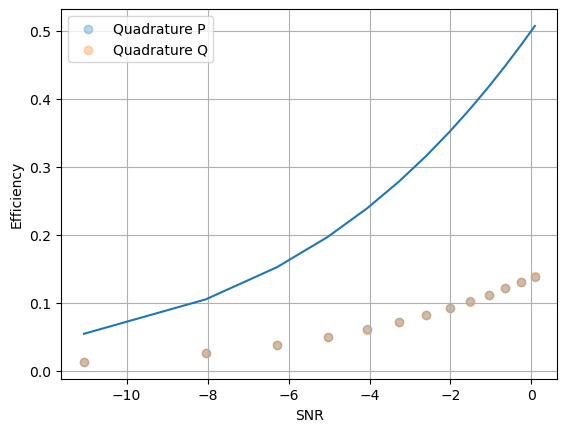

In [26]:
### To calculate the method efficiecy, we use: beta = soma(Pe_i) / capacity_awgn
import matplotlib.pyplot as plt
Capacity_awgn = 1/2 * np.log2(1+SNR_list)

#beta = df.groupby(["SNR", "Quadratura"]).apply(
#    lambda x: x["C"].sum()
#)

# distância KL entre duas Gaussianas de mesma média e variâncias diferentes (colocando as variâncias em função do nosso modelo, T e xi)
#com essa distância KL, a gente pode tentar descobrir o quanto que degenera I(U;V) se a gente tiver um erro na estimação da SNR de Bob,
#já que na prática, a SNR é estimada né.
#Como essa divergência na correlação entre as sequências de Alice e Bob vai impactar a informação mútua entre Alice e Bob?
beta = df.groupby(["SNR", "Quadrature"])["Capacity"].sum().reset_index()

display(beta)

for quad in beta["Quadrature"].unique():
    subset = beta[beta["Quadrature"] == quad]

    plt.scatter(
        subset["SNR"],
        subset["Capacity"],
        label=f"Quadrature {quad}",
        alpha=0.3
    )

#beta=beta/Capacity_awgn
plt.plot(SNRdB_list, Capacity_awgn)
plt.xlabel("SNR")
plt.ylabel("Efficiency")
plt.legend()
plt.grid()
plt.show()